In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [5]:
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)


performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)


fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)


In [6]:
nav.head()

,amfi_code,date,nav,daily_return_pct
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [7]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [8]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [10]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

In [11]:
nav.head()

,amfi_code,date,nav,daily_return_pct
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [13]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

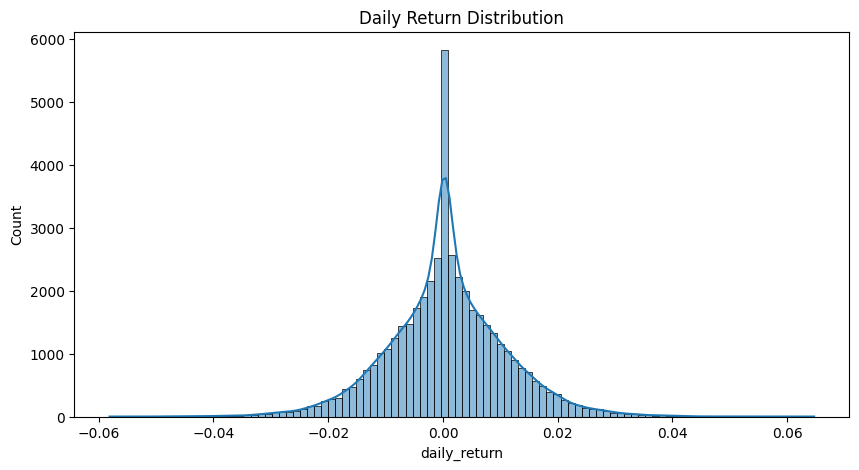

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title(
    'Daily Return Distribution'
)

plt.show()

In [15]:
def calculate_cagr(start_nav,end_nav,years):
    return (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

In [16]:
cagr_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code']==fund
    ]

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max()
        -
        temp['date'].min()
    ).days/365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code','cagr']
)

In [18]:
RF = 0.065

sharpe_list = []

for fund in nav['amfi_code'].unique():

    r = nav[
        nav['amfi_code']==fund
    ]['daily_return'].dropna()

    sharpe = (
        (r.mean()*252 - RF)
        /
        (r.std())
    ) * np.sqrt(252)

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=['amfi_code','sharpe_ratio']
)

In [19]:
sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

In [20]:
sortino_list = []

for fund in nav['amfi_code'].unique():

    r = nav[
        nav['amfi_code']==fund
    ]['daily_return'].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean()*252 - RF)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=['amfi_code','sortino_ratio']
)

In [23]:
benchmark = pd.read_csv(
    '../data/raw/10_benchmark_indices.csv'
)

print(benchmark.columns)

benchmark.head()

Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [24]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [25]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [26]:
print(nifty100.shape)

(1150, 3)


In [27]:
nifty100 = nifty100.sort_values(
    'date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [29]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ].copy()

    merged = pd.merge(
        fund_data[
            ['date','daily_return']
        ],
        nifty100[
            ['date','benchmark_return']
        ],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta_results.append(
            [
                fund,
                alpha,
                beta
            ]
        )

In [30]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [31]:
alpha_beta_df.to_csv(
    '../reports/alpha_beta.csv',
    index=False
)

In [32]:
mdd_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp['running_max'] = (
        temp['nav']
        .cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        - 1
    )

    mdd = temp['drawdown'].min()

    mdd_results.append(
        [
            fund,
            mdd
        ]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [33]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(mdd_df)
)

In [34]:
scorecard['return_rank'] = (
    scorecard['cagr']
    .rank(
        ascending=False
    )
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(
        ascending=False
    )
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(
        ascending=False
    )
)

scorecard['dd_rank'] = (
    scorecard['max_drawdown']
    .rank(
        ascending=True
    )
)

In [35]:
scorecard['fund_score'] = (
      scorecard['return_rank'] * 0.30
    + scorecard['sharpe_rank'] * 0.25
    + scorecard['alpha_rank'] * 0.20
    + scorecard['dd_rank'] * 0.10
)

In [36]:
scorecard['fund_score'] = (
    (
        scorecard['fund_score']
        -
        scorecard['fund_score'].min()
    )
    /
    (
        scorecard['fund_score'].max()
        -
        scorecard['fund_score'].min()
    )
) * 100

In [37]:
scorecard.to_csv(
    '../reports/fund_scorecard.csv',
    index=False
)

In [38]:
top5 = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
    .head(5)
)

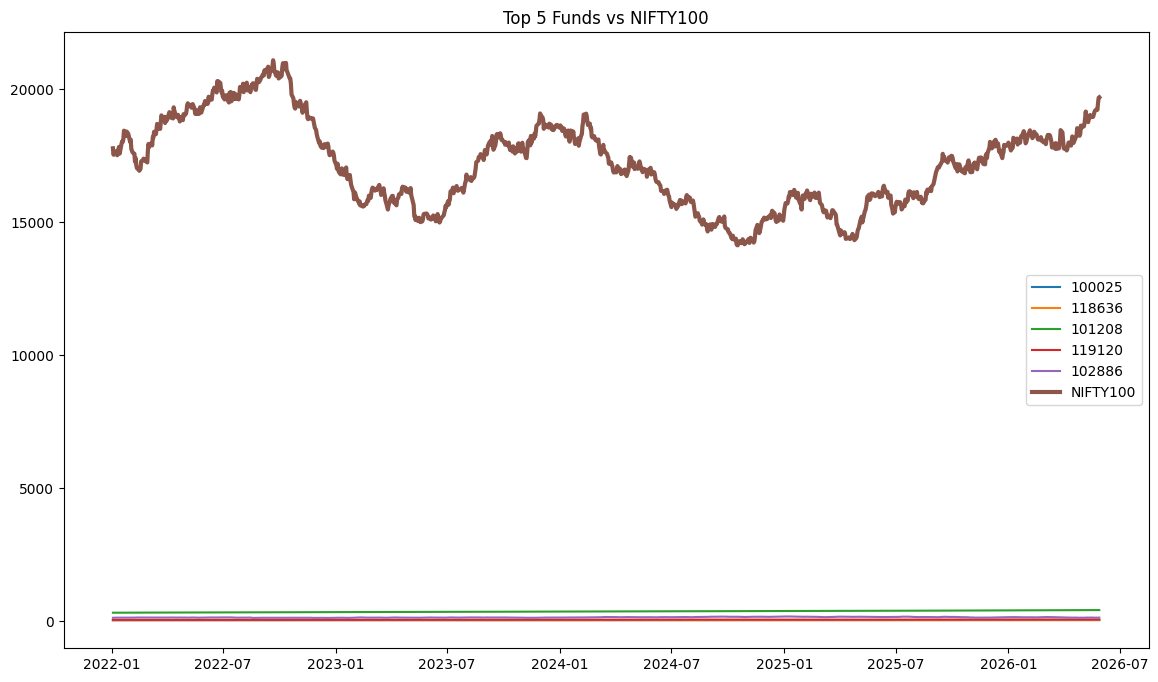

In [40]:
plt.figure(figsize=(14,8))

for fund in top5['amfi_code']:

    temp = nav[
        nav['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=fund
    )

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    linewidth=3,
    label='NIFTY100'
)

plt.legend()

plt.title(
    'Top 5 Funds vs NIFTY100'
)

plt.savefig(
    '../charts/benchmark_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()